In [1]:
import numpy as np
import matplotlib.pyplot as plt
from quantumScarFunctions_PXP import *
from quantumScarsPlotting import *

In [ ]:
N = 4
wd = 0.6366896896896898
wm = 1.0
tlist = np.linspace(0, 200, 600)
args = {"A": 0.1, "omega": wd}
reals = 1

dx = 0.0
dy = 0.0
dz = 0.0

H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)

scarIndices, scarStates = giveMeScarOverlap(N, psi0, tlist, disorder=[dz, dy, dx], reals=reals, args=args, plot_arc=True)
# vn_plot = plot_scar_vn_entrop(N, wd, tlist=tlist, disorder=[dz, dy, dx], reals=reals)

In [ ]:
# plt.figure(figsize=(20, 20))

# eigenvalues = H0.eigenenergies()
# xlist = np.linspace(0, len(eigenvalues), len(eigenvalues))
# plt.plot(xlist, eigenvalues, ".", ms=12)

# slist = []
# scarVals = []
# for i in scarIndices:
#     slist.append(xlist[i])
#     scarVals.append(eigenvalues[i])

# plt.plot(slist, scarVals, ".", ms=12)
# plt.grid(True)
# plt.xlabel("Eigenvalue")
# plt.ylabel("Energy")
# plt.grid(True, alpha=0.4)
# plt.title(f"Energies of Eigenvalues N={N}")
# plt.show()

In [ ]:
tol = 1e-8
eigs = eigenvalues
non_degen_states = []

for idx, val in enumerate(eigs):
    close_count = np.sum(np.abs(eigs - val) < tol)
    
    if close_count == 1:
        non_degen_states.append(idx)

print(non_degen_states) # excludes 0 energy scar

# print(len(non_degen_states) - len(scarIndices) + 1)

print(scarIndices)

scarList = [0, 1, 8, 33, 99, 266, 597, 1155, 1942]
scarSpacings = []
for i in range(len(scarList) - 1):
    scarSpacings.append(scarList[i+1] - scarList[i])
print(scarSpacings)

[0, 1, 8, 17, 30, 33, 56, 61, 74, 75, 86, 99, 108, 109, 114, 125, 144, 145, 176, 189, 192, 193, 196, 199, 206, 217, 224, 227, 240, 241, 262, 263, 266, 271, 282, 289, 290, 295, 316, 319, 322, 345, 376, 389, 390, 391, 406, 407, 422, 437, 438, 439, 442, 457, 470, 471, 482, 485, 520, 533, 542, 547, 548, 549, 552, 573, 580, 597, 604, 605, 606, 607, 608, 611, 622, 633, 668, 689, 694, 723, 724, 737, 740, 747, 748, 755, 762, 773, 774, 777, 784, 809, 810, 813, 814, 823, 824, 839, 856, 871, 874, 899, 904, 909, 938, 951, 952, 979, 980, 983, 1002, 1005, 1036, 1059, 1072, 1073, 1078, 1079, 1086, 1087, 1088, 1089, 1092, 1103, 1104, 1109, 1112, 1137, 1148, 1149, 1154, 1155, 1160, 1161, 1190, 1193, 1194, 1197, 1204, 1205, 1208, 1217, 1218, 1219, 1220, 1225, 1230, 1231, 1256, 1281, 1330, 1333, 1340, 1341, 1352, 1357, 1422, 1425, 1426, 1427, 1428, 1429, 1442, 1445, 1454, 1467, 1468, 1473, 1490, 1491, 1492, 1499, 1504, 1507, 1508, 1527, 1528, 1585, 1602, 1603, 1618, 1619, 1622, 1623, 1688, 1699, 1704, 17

poly fit: y = 210.7x + -387.1,  R^2 = 0.72473,  R^2_adj = 0.63297


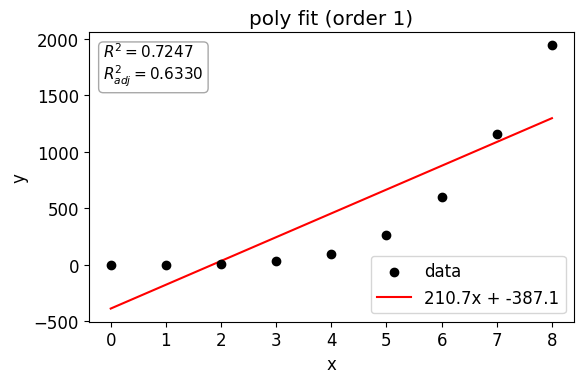

poly fit: y = 54.72x^2 + -227.1x + 123.7,  R^2 = 0.97573,  R^2_adj = 0.96116


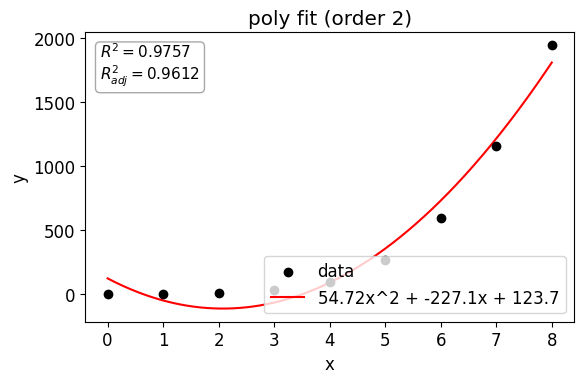

poly fit: y = 7.875x^3 + -39.78x^2 + 57.98x + -8.616,  R^2 = 0.99979,  R^2_adj = 0.99958


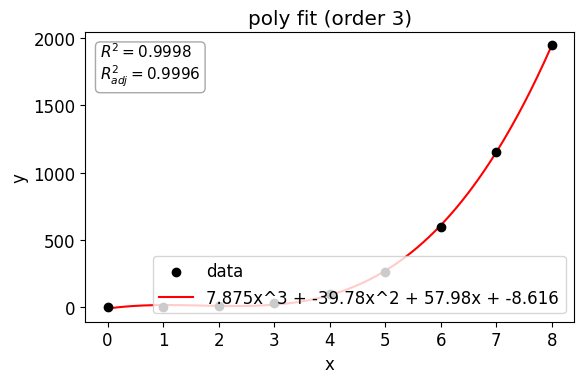

A = 13.78 ± 3.3,  k = 0.621 ± 0.032
exp fit: y = 13.78 exp(0.621 x),  R^2 = 0.99404,  R^2_adj = 0.99205


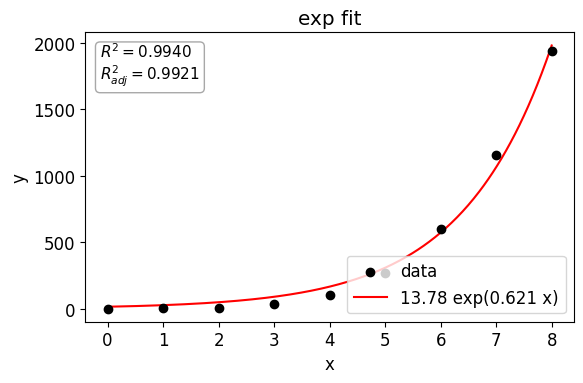

(array([13.78183762,  0.62104475]),
 <function __main__.fit_curve.<locals>.<lambda>(t)>,
 np.float64(0.9940390971837839),
 np.float64(0.9920521295783785))

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def fit_curve(x, y, model="poly", order=1, plot=True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    xs = np.linspace(x.min(), x.max(), 400)

    if model == "poly":
        coeffs = np.polyfit(x, y, order)
        f = np.poly1d(coeffs)
        label = " + ".join(
            f"{c:.4g}x^{order-i}" if order - i > 1
            else (f"{c:.4g}x" if order - i == 1 else f"{c:.4g}")
            for i, c in enumerate(coeffs)
        )
        params = coeffs

    elif model == "exp":
        # y = A * exp(k*x); seed from a fit of log(y) vs x
        mask = y > 0
        k0, lnA0 = np.polyfit(x[mask], np.log(y[mask]), 1)
        params, cov = curve_fit(
            lambda t, A, k: A * np.exp(k * t), x, y, p0=[np.exp(lnA0), k0]
        )
        f = lambda t: params[0] * np.exp(params[1] * t)
        perr = np.sqrt(np.diag(cov))
        label = f"{params[0]:.4g} exp({params[1]:.4g} x)"
        print(f"A = {params[0]:.4g} ± {perr[0]:.2g},  k = {params[1]:.4g} ± {perr[1]:.2g}")

    else:
        raise ValueError("model must be 'poly' or 'exp'")

    resid = y - f(x)
    r2 = 1 - np.sum(resid**2) / np.sum((y - y.mean()) ** 2)

    n, p = len(x), len(np.atleast_1d(params))
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - p - 1) if n > p + 1 else np.nan

    print(f"{model} fit: y = {label},  R^2 = {r2:.5f},  R^2_adj = {r2_adj:.5f}")

    if plot:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.scatter(x, y, color="k", zorder=3, label="data")
        ax.plot(xs, f(xs), "r-", label=label)

        stats = f"$R^2 = {r2:.4f}$"
        if not np.isnan(r2_adj):
            stats += f"\n$R^2_{{adj}} = {r2_adj:.4f}$"
        ax.text(
            0.03, 0.97, stats,
            transform=ax.transAxes, va="top", ha="left", fontsize=11,
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="0.6", alpha=0.85),
        )

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_title(f"{model} fit" + (f" (order {order})" if model == "poly" else ""))
        ax.legend(loc="lower right")
        fig.tight_layout()
        plt.show()

    return params, f, r2, r2_adj


plotScarSpacings = [0, 1, 8, 33, 99, 266, 597, 1155, 1942]
xlist = np.linspace(0, len(plotScarSpacings) - 1, len(plotScarSpacings))

fit_curve(xlist, plotScarSpacings, "poly", order=1)   # straight line
fit_curve(xlist, plotScarSpacings, "poly", order=2)   # quadratic
fit_curve(xlist, plotScarSpacings, "poly", order=3)   # cubic
fit_curve(xlist, plotScarSpacings, "exp")             # y = A e^{kx}

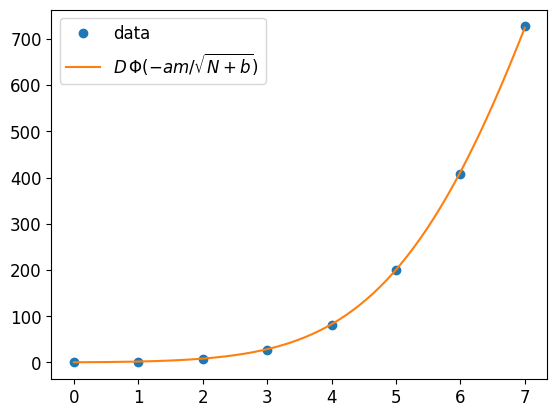

In [7]:
from scipy.stats import norm

plotScarSpacings = [0, 1, 8, 26, 81, 201, 407, 727]
N, a, b = 16, 1.693, -1.531
D = 2207                                    # L_16, the blockaded dimension

xlist = np.linspace(0, len(plotScarSpacings) - 1, 200)   # 200 pts -> smooth curve
m = len(plotScarSpacings) - xlist                        # tower steps below E=0
ylist = D * norm.cdf(-a * m / np.sqrt(N + b))

plt.plot(np.arange(len(plotScarSpacings)), plotScarSpacings, 'o', label='data')
plt.plot(xlist, ylist, '-', label='$D\\,\\Phi(-am/\\sqrt{N+b})$')
plt.legend()

In [ ]:
# FORMAT
# N QUBITS
# SCAR INDICES
# SCAR SPACINGS

# 4
# 0, 1
# 1

# 6
# 0, 1, 4
# 1, 3

# 8
# 0, 1, 4, 12
# 1, 3, 8

# 10
# 0, 1, 6, 14, 34
# 1, 5, 8, 20

# 12
# 0, 1, 6, 20, 48, 100
# 1, 5, 14, 28, 52

# 14
# 0, 1, 6, 22, 67, 141, 268
# 1, 5, 16, 45, 74, 127

# 16
# 0, 1, 8, 26, 81, 201, 407, 727
# 1, 7, 18, 55, 120, 206, 320

# 18
# 0, 1, 8, 33, 99, 266, 597, 1155, 1942
# 1, 7, 25, 66, 167, 331, 558, 787